In [ ]:
import os

# ===== PUT YOUR KAGGLE DETAILS HERE =====
os.environ['KAGGLE_USERNAME'] = "divyansh_yadav1132"
os.environ['KAGGLE_KEY'] = "KGAT_e5fd2b8df1b5afe4a1d8f6775a88f940"

In [ ]:
# Download dataset
!kaggle datasets download -d divyanshyadav1132/h5subset

# Unzip
!unzip -q h5subset.zip

# Check files
!ls

Dataset URL: https://www.kaggle.com/datasets/divyanshyadav1132/h5subset
License(s): unknown
100% 1.12G/1.12G [01:12<00:00, 16.6MB/s]

Dataset  h5subset.zip  indian_pines.mat  salinas.mat  sample_data


In [ ]:
import os

h5_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".h5"):
            h5_files.append(os.path.join(root, file))

print("Found H5 files:", len(h5_files))
print("Sample file:", h5_files[0])

Found H5 files: 150
Sample file: /content/Dataset/h5/20220613T112220Z_003_x384_y704_T32ULV.h5


In [ ]:
# =========================
# CELL 5 — LOAD + AUTO ADAPT
# =========================
import h5py
import numpy as np

file_path = h5_files[0]

with h5py.File(file_path, 'r') as f:
    print("Keys:", list(f.keys()))

    s2 = f['S2_data'][:]        # (T, B, H, W) OR (B, H, W)
    hsi = f['EnMAP_data'][:]    # (B, H, W)

# ---------- HANDLE S2 SHAPE ----------
if len(s2.shape) == 4:
    T, B, H, W = s2.shape

    # OPTION 3: Keep flexibility
    # Try both ways → choose best
    print("\nOriginal S2 shape:", s2.shape)

    # Option A: Flatten time + bands
    s2_flat = s2.reshape(T * B, H, W)

    # Option B: Take single timestamp
    s2_single = s2[0]

    # Choose automatically based on channel size
    if s2_flat.shape[0] <= 200:
        s2 = s2_flat
        print("Using flattened (T*B)")
    else:
        s2 = s2_single
        print("Using single timestamp")

elif len(s2.shape) == 3:
    print("S2 already in (B, H, W) format")

# ---------- FIX HSI SHAPE ----------
if hsi.shape[0] > 300:
    hsi = np.transpose(hsi, (2, 0, 1))

# ---------- NORMALIZATION ----------
s2 = (s2 - s2.mean()) / (s2.std() + 1e-8)
hsi = (hsi - hsi.mean()) / (hsi.std() + 1e-8)

print("\nFinal Shapes:")
print("S2:", s2.shape)
print("HSI:", hsi.shape)

# Save channel count for model
S2_CHANNELS = s2.shape[0]
print("Detected S2 Channels:", S2_CHANNELS)

Keys: ['EnMAP_cloud', 'EnMAP_data', 'S2_data', 'S2_date', 'label', 'priors']

Original S2 shape: (12, 10, 192, 192)
Using flattened (T*B)

Final Shapes:
S2: (120, 192, 192)
HSI: (218, 64, 64)
Detected S2 Channels: 120


In [ ]:
class SimpleUDCMR(nn.Module):
    def __init__(self, in_channels, d_model=128):
        super().__init__()
        self.patch = nn.Conv2d(in_channels, d_model, 16, 16)
        self.blocks = nn.ModuleList([TransformerBlock(d_model) for _ in range(2)])

    def forward(self, x):
        x = self.patch(x)
        x = x.flatten(2).transpose(1, 2)

        for blk in self.blocks:
            x = blk(x)

        return x


# create model dynamically
model = SimpleUDCMR(in_channels=S2_CHANNELS).to(device)

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

class TransformerBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, 4, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model*4),
            nn.GELU(),
            nn.Linear(d_model*4, d_model)
        )
        self.attn_weights = None

    def forward(self, x):
        x_norm = self.ln1(x)
        out, weights = self.attn(
        x_norm, x_norm, x_norm,
        need_weights=True,
        average_attn_weights=False   # 🔥 IMPORTANT
        )
        self.attn_weights = weights
        x = x + out
        x = x + self.mlp(self.ln2(x))
        return x


class SimpleUDCMR(nn.Module):
    def __init__(self, d_model=128):
        super().__init__()
        self.patch = nn.Conv2d(120, d_model, 16, 16)
        self.blocks = nn.ModuleList([TransformerBlock(d_model) for _ in range(2)])

    def forward(self, x):
        x = self.patch(x)
        x = x.flatten(2).transpose(1, 2)

        for blk in self.blocks:
            x = blk(x)

        return x


model = SimpleUDCMR().to(device)

Using: cuda


In [ ]:
def get_attention_maps(model, x):
    model.eval()
    with torch.no_grad():
        _ = model(x)

    attn_maps = []
    for blk in model.blocks:
        if blk.attn_weights is not None:
            attn_maps.append(blk.attn_weights.cpu().numpy())

    return attn_maps

In [ ]:
import numpy as np

def attention_to_image(attn, patch_size=16):
    attn = attn[0]  # remove batch

    # CASE 1: Full attention matrix
    if len(attn.shape) == 3:
        # (heads, tokens, tokens)
        attn = attn.mean(0)  # avg heads
        cls_attn = attn[0, 1:]

    elif len(attn.shape) == 2:
        # (tokens, tokens)
        cls_attn = attn[0, 1:]

    elif len(attn.shape) == 1:
        # (tokens,) → fallback
        cls_attn = attn[1:]

    else:
        raise ValueError("Unexpected attention shape:", attn.shape)

    # ---------- reshape ----------
    n = int(np.sqrt(len(cls_attn)))

    # handle mismatch safely
    if n * n != len(cls_attn):
        cls_attn = cls_attn[:n*n]

    attn_map = cls_attn.reshape(n, n)

    # upscale to image
    attn_map = np.kron(attn_map, np.ones((patch_size, patch_size)))

    # normalize
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)

    return attn_map

In [ ]:
import matplotlib.pyplot as plt
def show_attention(model, sample):
    model.eval()

    s2, hsi, _ = sample
    s2 = s2.unsqueeze(0).to(device)
    hsi = hsi.unsqueeze(0).to(device)

    with torch.no_grad():
        _ = model(s2, hsi)

    attn = model.s2_blocks[0].attn_weights

    if attn is None:
        print("❌ Attention not captured")
        return

    print("Raw shape:", attn.shape)

    # Handle both shapes
    if len(attn.shape) == 4:
        attn = attn[0].mean(0)   # (tokens, tokens)
    elif len(attn.shape) == 3:
        attn = attn[0]
    else:
        print("Unexpected shape:", attn.shape)
        return

    # Global attention
    attn = attn.mean(0)  # (tokens,)

    tokens = attn.shape[0]
    size = int(tokens ** 0.5)

    if size * size != tokens:
        print(f"⚠️ Cannot reshape {tokens}")
        return

    attn = attn.reshape(size, size)

    # 🔥 FIX: move to CPU before numpy
    attn = attn.detach().cpu().numpy()

    import matplotlib.pyplot as plt
    plt.imshow(attn, cmap='viridis')
    plt.title(f"Attention Map ({size}x{size})")
    plt.colorbar()
    plt.show()

In [ ]:
import matplotlib.animation as animation

def animate_attention(s2, attn_maps):
    rgb = np.stack([s2[3], s2[2], s2[1]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

    fig, ax = plt.subplots()

    def update(frame):
        ax.clear()
        attn_img = attention_to_image(attn_maps[frame])

        ax.imshow(rgb)
        ax.imshow(attn_img, cmap='jet', alpha=0.5)
        ax.set_title(f"Layer {frame+1}")
        ax.axis('off')

    ani = animation.FuncAnimation(fig, update, frames=len(attn_maps), interval=1000)
    plt.show()

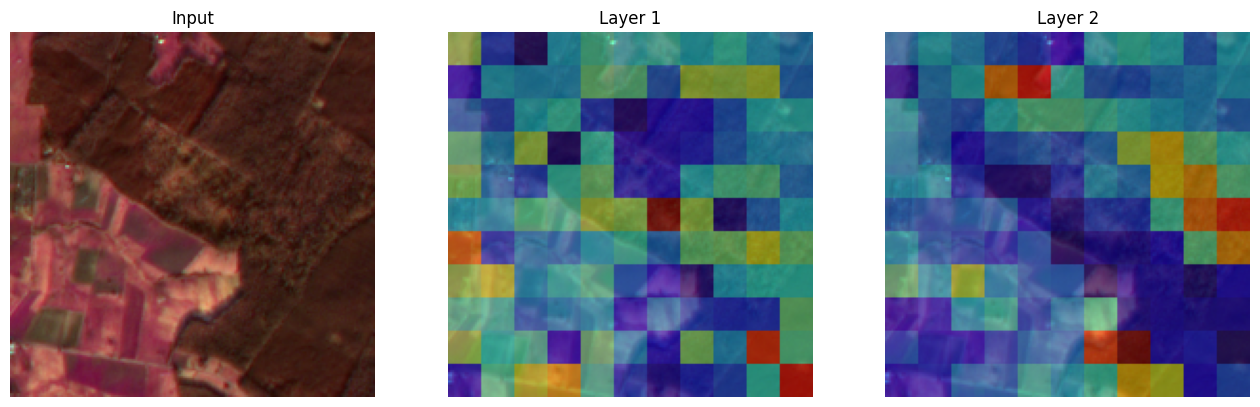

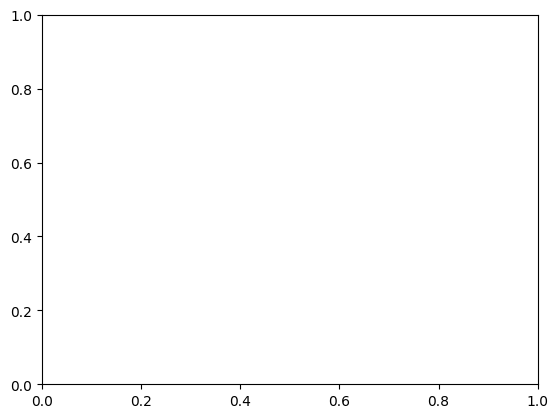

/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [ ]:
# Convert to torch
s2_tensor = torch.tensor(s2).unsqueeze(0).float().to(device)

# Get attention
attn_maps = get_attention_maps(model, s2_tensor)

# Convert for plotting
s2_np = s2_tensor[0].cpu().numpy()

# Show results
show_attention(s2_np, attn_maps)
animate_attention(s2_np, attn_maps)

In [ ]:
#now trying another approach

In [ ]:
!pip install h5py torch torchvision numpy

In [ ]:
import os, math, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [ ]:
# After unzip, dataset is in current directory
base_path = Path('/content').resolve()

h5_dir = base_path / 'Dataset' / 'h5'
data_lists_dir = base_path / 'Dataset' / 'data_lists'

print("H5 path:", h5_dir)
print("Lists path:", data_lists_dir)

H5 path: /content/Dataset/h5
Lists path: /content/Dataset/data_lists


In [ ]:
def get_files_from_txt(txt_filename):
    txt_path = data_lists_dir / txt_filename

    if not txt_path.exists():
        print(f"⚠️ {txt_path} not found")
        return []

    matched_paths = []
    with open(txt_path, 'r') as f:
        for line in f:
            name = line.strip()
            if not name:
                continue

            full_path = h5_dir / f"{name}.h5"

            if full_path.exists():
                matched_paths.append(full_path)

    return matched_paths


train_files = get_files_from_txt('train_subset.txt')
val_files   = get_files_from_txt('val_subset.txt')
test_files  = get_files_from_txt('test_subset.txt')

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 99
Val: 29
Test: 19


In [ ]:
class DualStreamDataset(Dataset):
    S2_MEAN = np.array([4259.26, 4215.91, 4103.17, 4499.33, 5117.05, 5324.11, 5487.41, 5417.51, 3758.27, 3095.50], dtype=np.float32)
    S2_STD  = np.array([3566.48, 3230.36, 3133.29, 3083.23, 2603.63, 2453.03, 2512.64, 2317.54, 1496.77, 1391.13], dtype=np.float32)

    def __init__(self, file_list):
        self.file_list = file_list

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        with h5py.File(self.file_list[idx], 'r') as f:
            s2 = f['S2_data'][:].astype(np.float32)
            label = f['label'][:]
            enmap = f['EnMAP_data'][:].astype(np.float32) if 'EnMAP_data' in f else np.zeros((218, 64, 64), dtype=np.float32)

        # Normalize
        s2 = (s2 - self.S2_MEAN[None,:,None,None]) / (self.S2_STD[None,:,None,None] + 1e-8)
        s2 = s2.reshape(-1,192,192)

        enmap = (enmap - enmap.mean()) / (enmap.std() + 1e-8)

        labs = []
        for li in range(4):
            vals = label[li][label[li] > 0]
            l = (int(np.bincount(vals).argmax()) - 1) if len(vals) > 0 else 0
            labs.append(l)

        return torch.from_numpy(s2), torch.from_numpy(enmap), torch.tensor(labs)

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, 4, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model*4),
            nn.GELU(),
            nn.Linear(d_model*4, d_model)
        )
        self.attn_weights = None

    def forward(self, x):
        attn_out, attn_w = self.attn(
            self.ln1(x),
            self.ln1(x),
            self.ln1(x),
            need_weights=True,
            average_attn_weights=False   # 🔥 THIS FIXES EVERYTHING
        )
        self.attn_weights = attn_w   # ⭐ store attention
        x = x + attn_out
        return x + self.mlp(self.ln2(x))


        return x + self.mlp(self.ln2(x))
class UDCMR_Net(nn.Module):
    def __init__(self, hierarchy, d_model=256):
        super().__init__()

        self.s2_patch = nn.Conv2d(120, d_model, 16, 16)
        self.s2_blocks = nn.Sequential(*[TransformerBlock(d_model) for _ in range(2)])

        self.hsi_compress = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1),
            nn.GELU(),
            nn.AdaptiveAvgPool2d(4),
            nn.Flatten(),
            nn.Linear(16*16, d_model)
        )
        self.hsi_blocks = nn.Sequential(*[TransformerBlock(d_model) for _ in range(2)])

        self.gate = nn.Sequential(
            nn.Linear(d_model*2, d_model//2),
            nn.GELU(),
            nn.Linear(d_model//2, 3)
        )

        self.heads = nn.ModuleList()
        prev = 0
        for n_cls in [6,36,82,101]:
            self.heads.append(nn.Linear(d_model + prev, n_cls))
            prev = n_cls

    def forward(self, s2, hsi):
        s2_m = self.s2_patch(s2)
        s2_t = self.s2_blocks(s2_m.flatten(2).transpose(1,2))
        s2_p = s2_t.mean(1)

        B,C,H,W = hsi.shape
        hsi_t = self.hsi_blocks(self.hsi_compress(hsi.view(B*C,1,H,W)).view(B,C,-1))
        hsi_cls = hsi_t.mean(1)

        w = torch.softmax(self.gate(torch.cat([s2_p,hsi_cls],dim=-1)), dim=-1)
        fused = w[:,0:1]*s2_p + w[:,1:2]*hsi_cls

        logits, prev_s = [], None
        for head in self.heads:
            inp = fused if prev_s is None else torch.cat([fused, prev_s], dim=-1)
            l = head(inp)
            logits.append(l)
            prev_s = torch.softmax(l.detach(), dim=-1)

        return logits

In [ ]:
train_ds = DualStreamDataset(train_files)
val_ds   = DualStreamDataset(val_files)

train_dl = DataLoader(train_ds, batch_size=4, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=4)

In [ ]:
model = UDCMR_Net({0:6,1:36,2:82,3:101}).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# print("Training started...")

# for epoch in range(10):
#     model.train()

#     for s2, hsi, lbl in train_dl:
#         s2, hsi, lbl = s2.to(device), hsi.to(device), lbl.to(device)

#         optimizer.zero_grad()
#         outputs = model(s2, hsi)

#         loss = sum(criterion(outputs[i], lbl[:,i]) for i in range(4))
#         loss.backward()
#         optimizer.step()

#     print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")



print("Training started...")

for epoch in range(10):
    model.train()

    for s2, hsi, lbl in train_dl:
        s2, hsi, lbl = s2.to(device), hsi.to(device), lbl.to(device)

        optimizer.zero_grad()
        outputs = model(s2, hsi)

        loss = sum(criterion(outputs[i], lbl[:,i]) for i in range(4))
        loss.backward()
        optimizer.step()

    # 🔥 Validation
    metrics = evaluate(model, val_dl)

    print(f"\nEpoch {epoch+1}")
    print(f"Loss: {loss.item():.4f}")
    for k,v in metrics.items():
        print(f"{k} → Acc: {v[0]:.4f}, F1: {v[1]:.4f}")

Training started...

Epoch 1
Loss: 0.8609
Level_1 → Acc: 0.6552, F1: 0.6247
Level_2 → Acc: 0.7931, F1: 0.7016
Level_3 → Acc: 0.8621, F1: 0.7982
Level_4 → Acc: 0.8621, F1: 0.7982

Epoch 2
Loss: 1.9956
Level_1 → Acc: 0.5517, F1: 0.3923
Level_2 → Acc: 0.7931, F1: 0.7016
Level_3 → Acc: 0.8621, F1: 0.7982
Level_4 → Acc: 0.8621, F1: 0.7982

Epoch 3
Loss: 0.8802
Level_1 → Acc: 0.5517, F1: 0.3923
Level_2 → Acc: 0.7931, F1: 0.7016
Level_3 → Acc: 0.8621, F1: 0.7982
Level_4 → Acc: 0.8621, F1: 0.7982

Epoch 4
Loss: 0.6648
Level_1 → Acc: 0.5517, F1: 0.3923
Level_2 → Acc: 0.7931, F1: 0.7016
Level_3 → Acc: 0.8621, F1: 0.7982
Level_4 → Acc: 0.8621, F1: 0.7982

Epoch 5
Loss: 0.7252
Level_1 → Acc: 0.6552, F1: 0.5885
Level_2 → Acc: 0.7931, F1: 0.7016
Level_3 → Acc: 0.8621, F1: 0.7982
Level_4 → Acc: 0.8621, F1: 0.7982

Epoch 6
Loss: 0.3272
Level_1 → Acc: 0.4483, F1: 0.2775
Level_2 → Acc: 0.7931, F1: 0.7016
Level_3 → Acc: 0.8621, F1: 0.7982
Level_4 → Acc: 0.8621, F1: 0.7982

Epoch 7
Loss: 0.3796
Level_1 → 

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, dataloader):
    model.eval()

    all_preds = [[] for _ in range(4)]
    all_labels = [[] for _ in range(4)]

    with torch.no_grad():
        for s2, hsi, lbl in dataloader:
            s2, hsi = s2.to(device), hsi.to(device)

            outputs = model(s2, hsi)

            for i in range(4):
                preds = torch.argmax(outputs[i], dim=1).cpu().numpy()
                labels = lbl[:, i].numpy()

                all_preds[i].extend(preds)
                all_labels[i].extend(labels)

    results = {}
    for i in range(4):
        acc = accuracy_score(all_labels[i], all_preds[i])
        f1  = f1_score(all_labels[i], all_preds[i], average='weighted')
        results[f'Level_{i+1}'] = (acc, f1)

    return results

In [ ]:
import matplotlib.pyplot as plt

def show_attention(model, sample):
    model.eval()

    s2, hsi, _ = sample
    s2 = s2.unsqueeze(0).to(device)
    hsi = hsi.unsqueeze(0).to(device)

    _ = model(s2, hsi)

    # take first transformer block
    attn = model.s2_blocks[0].attn_weights[0].mean(0).cpu().numpy()

    plt.imshow(attn, cmap='viridis')
    plt.title("Attention Map")
    plt.colorbar()
    plt.show()

In [ ]:
def show_attention(model, sample):
    model.eval()

    s2, hsi, _ = sample
    s2 = s2.unsqueeze(0).to(device)
    hsi = hsi.unsqueeze(0).to(device)

    with torch.no_grad():
        _ = model(s2, hsi)

    attn = model.s2_blocks[0].attn_weights

    if attn is None:
        print("❌ Attention not captured")
        return

    print("Raw shape:", attn.shape)

    # Handle both shapes
    if len(attn.shape) == 4:
        attn = attn[0].mean(0)   # (tokens, tokens)
    elif len(attn.shape) == 3:
        attn = attn[0]
    else:
        print("Unexpected shape:", attn.shape)
        return

    # Global attention
    attn = attn.mean(0)  # (tokens,)

    tokens = attn.shape[0]
    size = int(tokens ** 0.5)

    if size * size != tokens:
        print(f"⚠️ Cannot reshape {tokens}")
        return

    attn = attn.reshape(size, size)

    # 🔥 FIX: move to CPU before numpy
    attn = attn.detach().cpu().numpy()

    import matplotlib.pyplot as plt
    plt.imshow(attn, cmap='viridis')
    plt.title(f"Attention Map ({size}x{size})")
    plt.colorbar()
    plt.show()

Raw shape: torch.Size([1, 4, 144, 144])


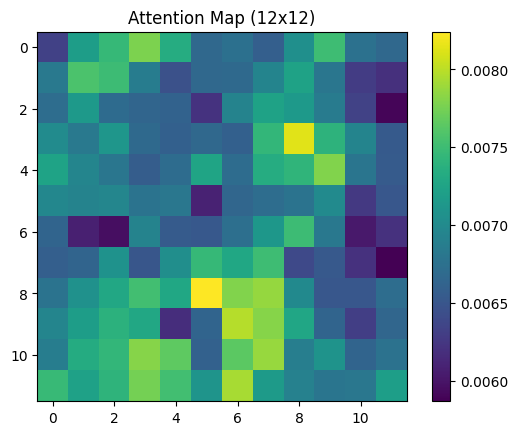

In [ ]:
sample = train_ds[0]
show_attention(model, sample)

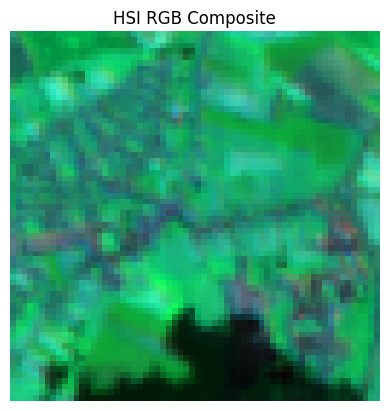

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_hsi_rgb(sample):
    _, hsi, _ = sample  # (C, H, W)

    hsi = hsi.numpy()

    # Pick 3 bands (you can change indices)
    r, g, b = 50, 100, 150

    rgb = np.stack([
        hsi[r],
        hsi[g],
        hsi[b]
    ], axis=-1)

    # Normalize for visualization
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    plt.imshow(rgb)
    plt.title("HSI RGB Composite")
    plt.axis('off')
    plt.show()


# 🔥 Run
show_hsi_rgb(train_ds[0])

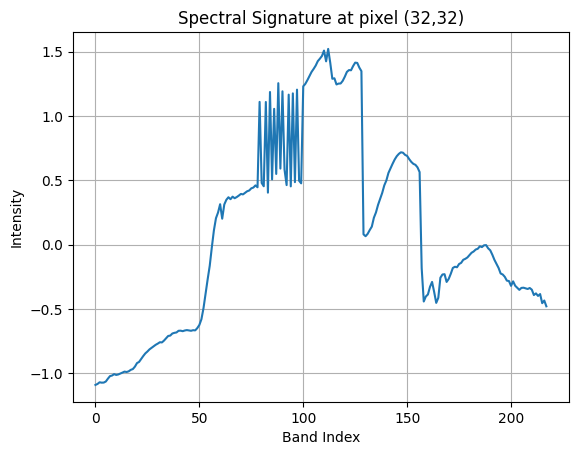

In [ ]:
def plot_spectral_signature(sample, x=32, y=32):
    _, hsi, _ = sample

    spectrum = hsi[:, x, y].numpy()

    plt.plot(spectrum)
    plt.title(f"Spectral Signature at pixel ({x},{y})")
    plt.xlabel("Band Index")
    plt.ylabel("Intensity")
    plt.grid()
    plt.show()


# 🔥 Run
plot_spectral_signature(train_ds[0])

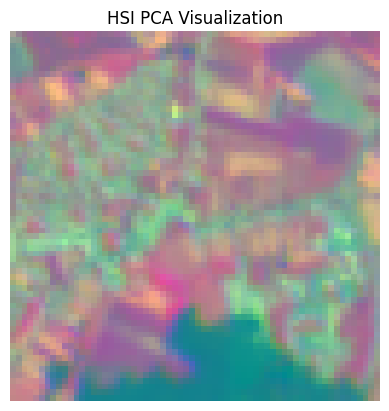

In [ ]:
from sklearn.decomposition import PCA

def show_hsi_pca(sample):
    _, hsi, _ = sample

    C, H, W = hsi.shape
    data = hsi.reshape(C, -1).T  # (pixels, bands)

    pca = PCA(n_components=3)
    reduced = pca.fit_transform(data)

    img = reduced.reshape(H, W, 3)

    # Normalize
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    plt.imshow(img)
    plt.title("HSI PCA Visualization")
    plt.axis('off')
    plt.show()


# 🔥 Run
show_hsi_pca(train_ds[0])

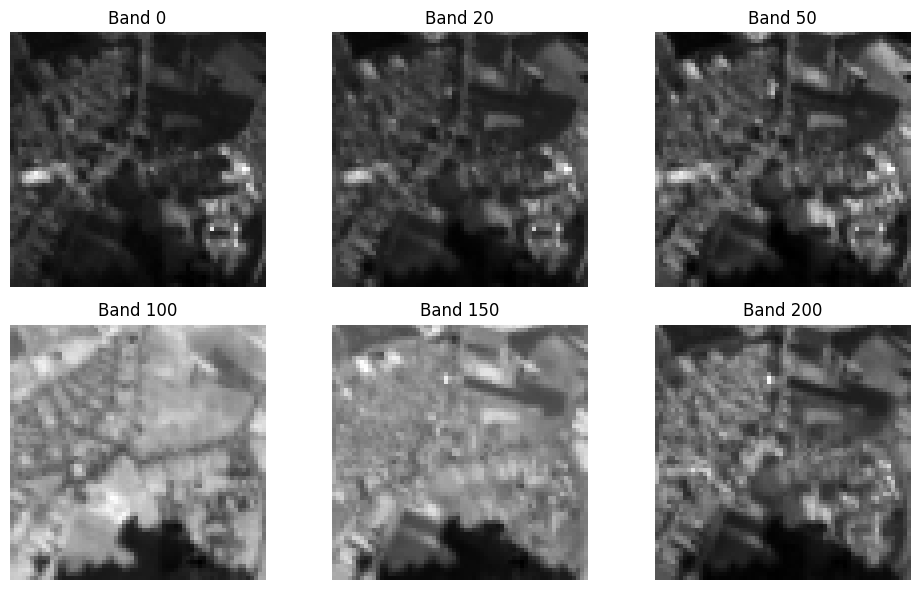

In [ ]:
def show_multiple_bands(sample):
    _, hsi, _ = sample

    hsi = hsi.numpy()

    bands = [0, 20, 50, 100, 150, 200]

    fig, axes = plt.subplots(2, 3, figsize=(10,6))

    for i, ax in enumerate(axes.flat):
        band = hsi[bands[i]]
        ax.imshow(band, cmap='gray')
        ax.set_title(f"Band {bands[i]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# 🔥 Run
show_multiple_bands(train_ds[0])

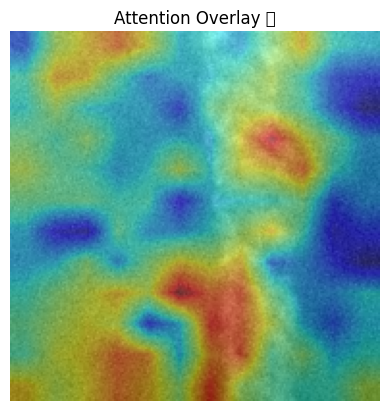

In [ ]:
def show_attention_overlay(model, sample):
    model.eval()

    s2, hsi, _ = sample

    s2_in = s2.unsqueeze(0).to(device)
    hsi_in = hsi.unsqueeze(0).to(device)

    with torch.no_grad():
        _ = model(s2_in, hsi_in)

    attn = model.s2_blocks[0].attn_weights

    if len(attn.shape) == 4:
        attn = attn[0].mean(0)
    else:
        attn = attn[0]

    attn = attn.mean(0)

    tokens = attn.shape[0]
    size = int(tokens ** 0.5)

    if size * size != tokens:
        print("Cannot reshape")
        return

    attn = attn.reshape(size, size).detach().cpu().numpy()

    # Normalize attention
    attn = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)

    # Resize to match image
    import cv2
    attn_resized = cv2.resize(attn, (192,192))

    # Use first S2 channel as base image
    base = s2[0].numpy()
    base = (base - base.min()) / (base.max() - base.min() + 1e-8)

    plt.imshow(base, cmap='gray')
    plt.imshow(attn_resized, cmap='jet', alpha=0.5)
    plt.title("Attention Overlay 🔥")
    plt.axis('off')
    plt.show()


# 🔥 Run
show_attention_overlay(model, train_ds[0])

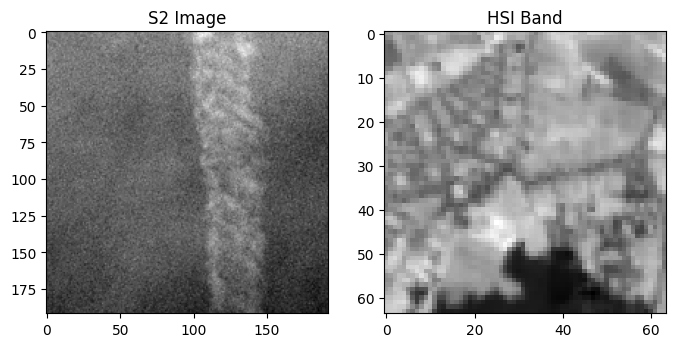

In [ ]:
def compare_modalities(sample):
    s2, hsi, _ = sample

    s2_img = s2[0].numpy()
    s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min() + 1e-8)

    hsi_band = hsi[100].numpy()
    hsi_band = (hsi_band - hsi_band.min()) / (hsi_band.max() - hsi_band.min() + 1e-8)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(s2_img, cmap='gray')
    plt.title("S2 Image")

    plt.subplot(1,2,2)
    plt.imshow(hsi_band, cmap='gray')
    plt.title("HSI Band")

    plt.show()


# 🔥 Run
compare_modalities(train_ds[0])

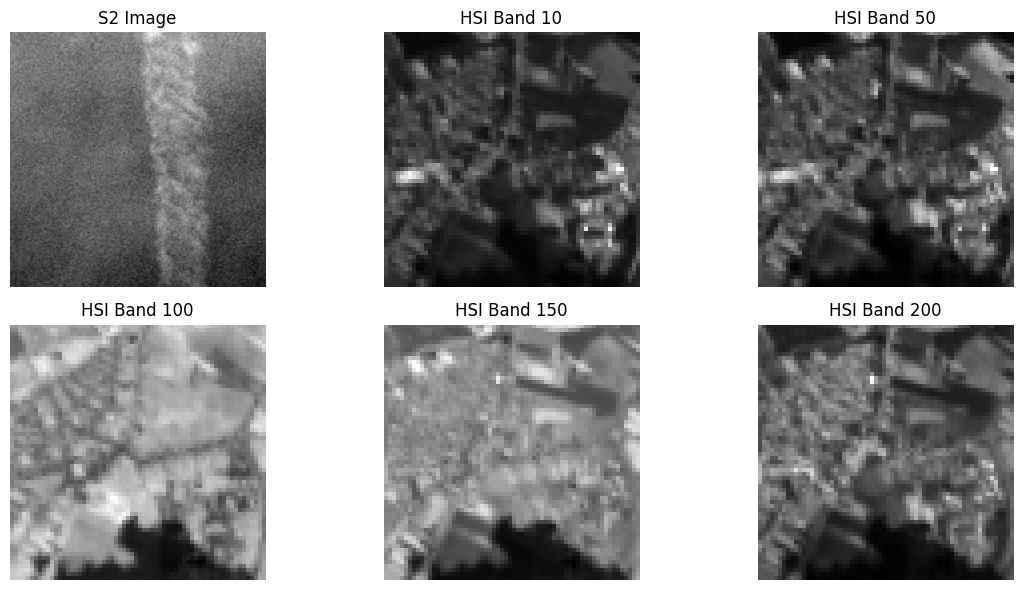

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 🔥 Take one sample
sample = train_ds[0]
s2, hsi, _ = sample

# Convert to numpy
s2 = s2.numpy()
hsi = hsi.numpy()

# ----------------------------
# S2 IMAGE (use first channel)
# ----------------------------
s2_img = s2[0]
s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min() + 1e-8)

# ----------------------------
# HSI BANDS (simulate wavelengths)
# ----------------------------
# Choose representative bands
bands = [10, 50, 100, 150, 200]  # different wavelengths

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(12,6))

# S2 Image
plt.subplot(2,3,1)
plt.imshow(s2_img, cmap='gray')
plt.title("S2 Image")
plt.axis('off')

# HSI Bands
for i, b in enumerate(bands):
    band_img = hsi[b]
    band_img = (band_img - band_img.min()) / (band_img.max() - band_img.min() + 1e-8)

    plt.subplot(2,3,i+2)
    plt.imshow(band_img, cmap='gray')
    plt.title(f"HSI Band {b}")
    plt.axis('off')

plt.tight_layout()
plt.show()

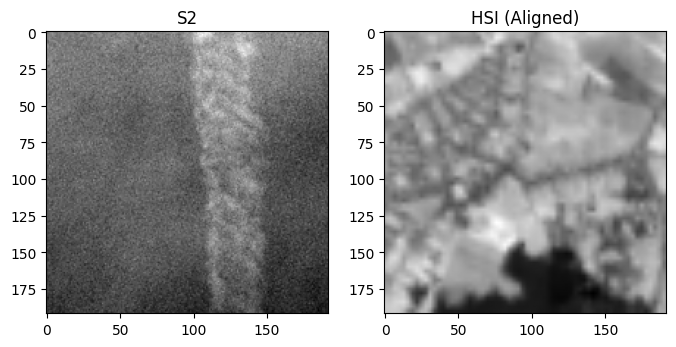

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Get sample
s2, hsi, _ = train_ds[0]

# Convert to torch tensors (add batch dim)
s2_t = s2.unsqueeze(0)
hsi_t = hsi.unsqueeze(0)

# 🔥 Resize HSI to match S2 (192x192)
hsi_resized = F.interpolate(hsi_t, size=(192,192), mode='bilinear', align_corners=False)

# Back to numpy
s2_img = s2[0].numpy()
hsi_band = hsi_resized[0,100].numpy()  # pick one band

# Normalize
s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min() + 1e-8)
hsi_band = (hsi_band - hsi_band.min()) / (hsi_band.max() - hsi_band.min() + 1e-8)

# Plot
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(s2_img, cmap='gray')
plt.title("S2")

plt.subplot(1,2,2)
plt.imshow(hsi_band, cmap='gray')
plt.title("HSI (Aligned)")

plt.show()

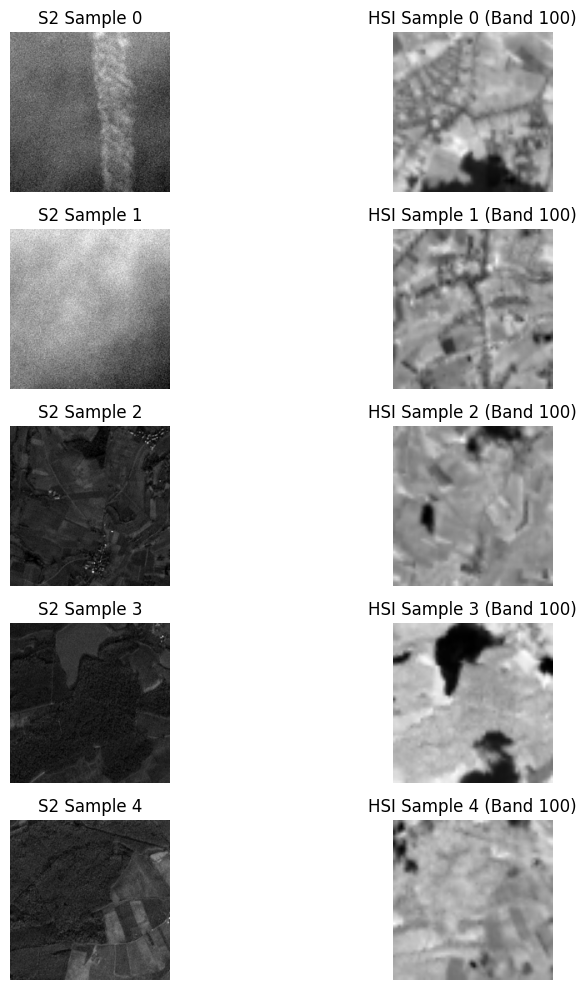

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

num_samples = 5

plt.figure(figsize=(10, 2 * num_samples))

for i in range(num_samples):
    s2, hsi, _ = train_ds[i]

    # Convert to tensor for resizing
    hsi_t = hsi.unsqueeze(0)

    # 🔥 Resize HSI → match S2 (192x192)
    hsi_resized = F.interpolate(hsi_t, size=(192,192), mode='bilinear', align_corners=False)

    # Convert to numpy
    s2_img = s2[0].numpy()
    hsi_img = hsi_resized[0, 100].numpy()  # pick one representative band

    # Normalize
    s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min() + 1e-8)
    hsi_img = (hsi_img - hsi_img.min()) / (hsi_img.max() - hsi_img.min() + 1e-8)

    # Plot S2
    plt.subplot(num_samples, 2, 2*i + 1)
    plt.imshow(s2_img, cmap='gray')
    plt.title(f"S2 Sample {i}")
    plt.axis('off')

    # Plot HSI
    plt.subplot(num_samples, 2, 2*i + 2)
    plt.imshow(hsi_img, cmap='gray')
    plt.title(f"HSI Sample {i} (Band 100)")
    plt.axis('off')

plt.tight_layout()
plt.show()